In [13]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, feature, color
from scipy import ndimage as ndi
import cv2

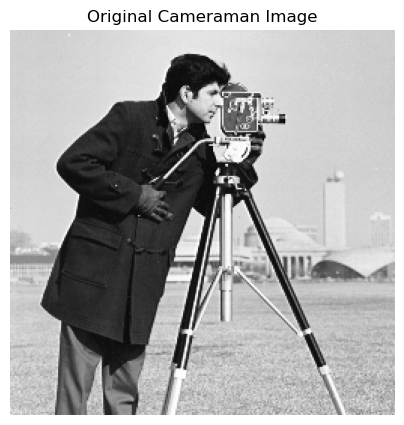

In [14]:
# Load the cameraman image from skimage
image = cv2.imread('test_images/cameraman.bmp', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(5,5))
plt.title("Original Cameraman Image")
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

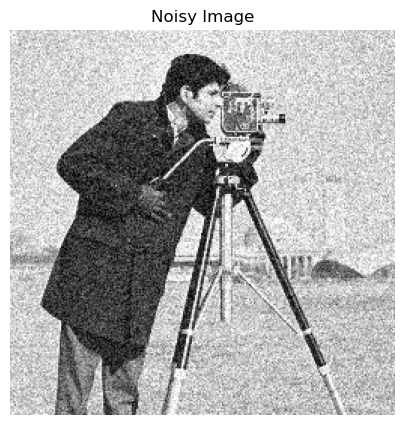

In [15]:
# Add Gaussian noise
noisy_image = util.random_noise(image, mode='gaussian', var=0.01)
noisy_image
noisy_image = (255*noisy_image).astype(np.uint8)
plt.figure(figsize=(5,5))
plt.title("Noisy Image")
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')
plt.show()

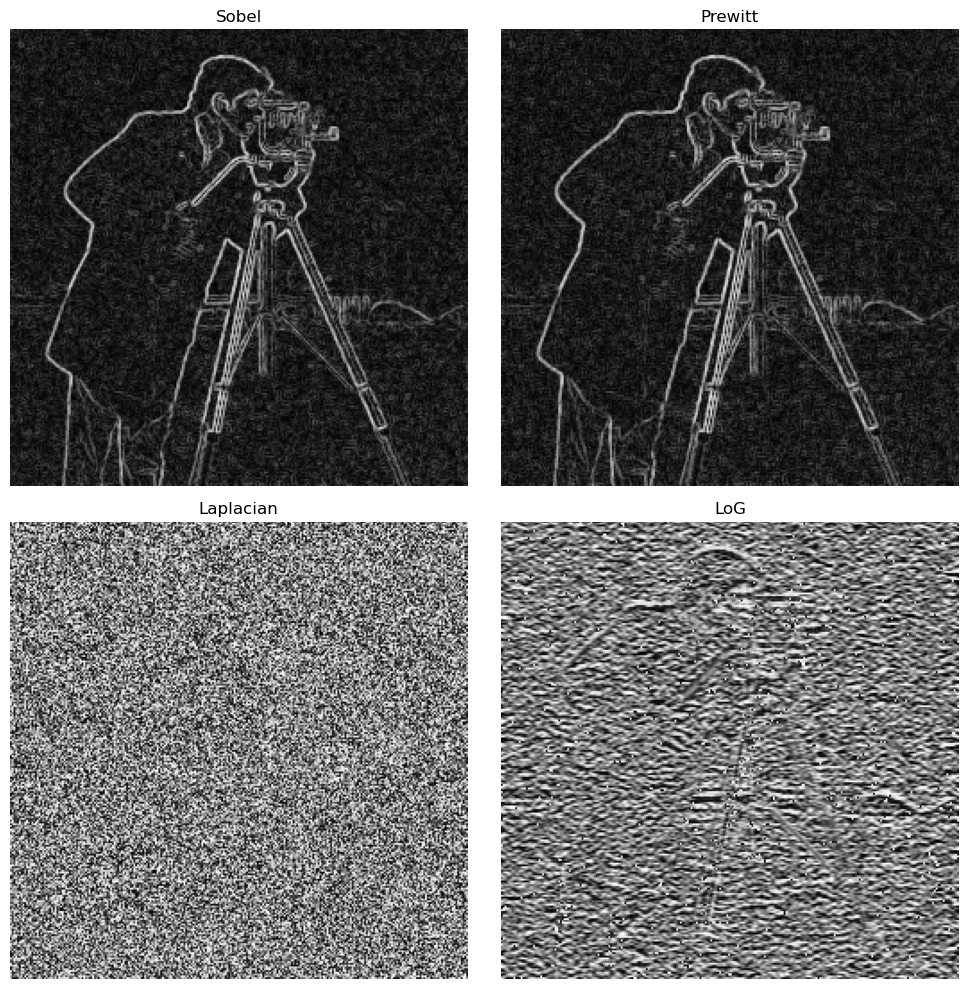

In [16]:
# Sobel
sobel_edges = filters.sobel(noisy_image)
# Prewitt
prewitt_edges = filters.prewitt(noisy_image)
# Laplacian
laplacian_edges = ndi.laplace(noisy_image)
# LoG (Laplacian of Gaussian)
log_edges = ndi.gaussian_laplace(noisy_image, sigma=1)

# Display all edge images
fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes[0,0].imshow(sobel_edges, cmap='gray')
axes[0,0].set_title('Sobel')
axes[0,1].imshow(prewitt_edges, cmap='gray')
axes[0,1].set_title('Prewitt')
axes[1,0].imshow(laplacian_edges, cmap='gray')
axes[1,0].set_title('Laplacian')
axes[1,1].imshow(log_edges, cmap='gray')
axes[1,1].set_title('LoG')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

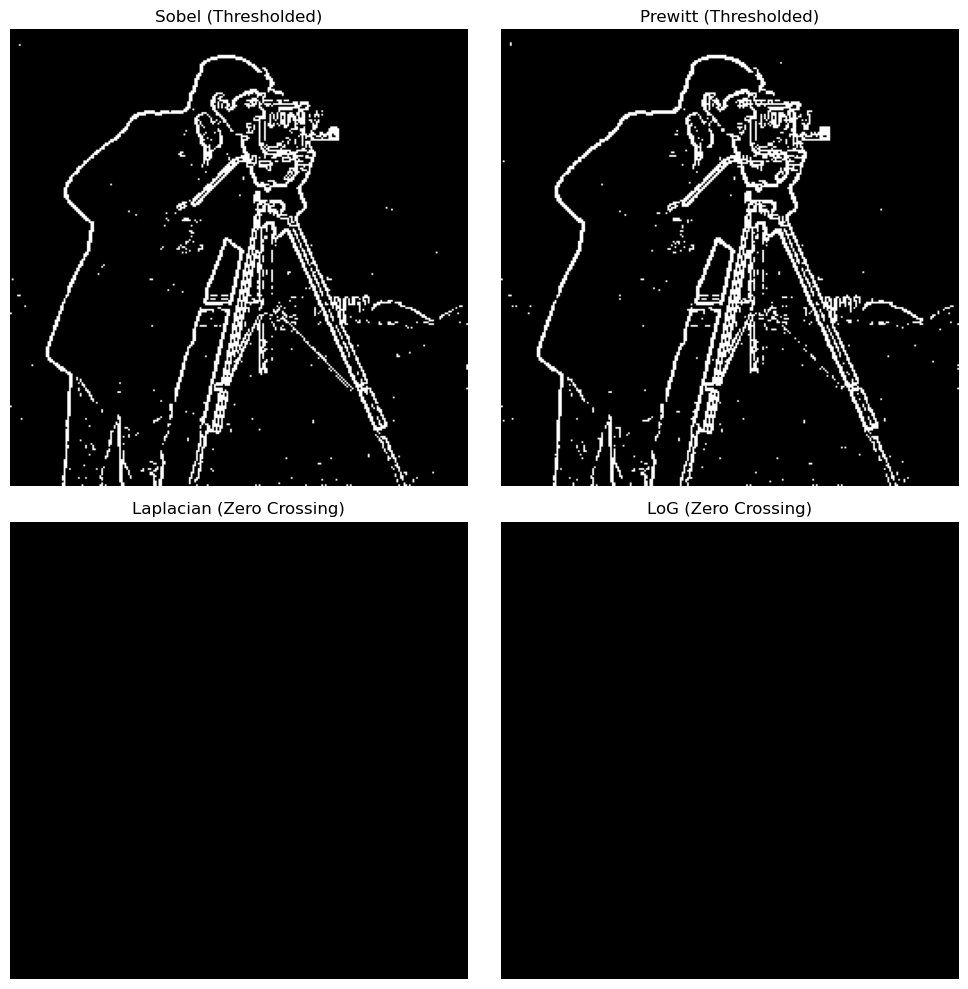

In [17]:
# Thresholding for Sobel and Prewitt
sobel_binary = sobel_edges > filters.threshold_otsu(sobel_edges)
prewitt_binary = prewitt_edges > filters.threshold_otsu(prewitt_edges)

# Zero crossing for Laplacian and LoG
def zero_crossing(image):
    zc = np.zeros(image.shape, dtype=bool)
    core = image[1:-1, 1:-1]
    # Check all 8 neighbors
    zc[1:-1, 1:-1] = (
        (core * image[:-2, 1:-1] < 0)   |  # up
        (core * image[2:, 1:-1] < 0)    |  # down
        (core * image[1:-1, :-2] < 0)   |  # left
        (core * image[1:-1, 2:] < 0)    |  # right
        (core * image[:-2, :-2] < 0)    |  # up-left
        (core * image[:-2, 2:] < 0)     |  # up-right
        (core * image[2:, :-2] < 0)     |  # down-left
        (core * image[2:, 2:] < 0)         # down-right
    )
    return zc
laplacian_zc = zero_crossing(laplacian_edges)
log_zc = zero_crossing(log_edges)

# Display binary/segmented images
fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes[0,0].imshow(sobel_binary, cmap='gray')
axes[0,0].set_title('Sobel (Thresholded)')
axes[0,1].imshow(prewitt_binary, cmap='gray')
axes[0,1].set_title('Prewitt (Thresholded)')
axes[1,0].imshow(laplacian_zc, cmap='gray')
axes[1,0].set_title('Laplacian (Zero Crossing)')
axes[1,1].imshow(log_zc, cmap='gray')
axes[1,1].set_title('LoG (Zero Crossing)')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

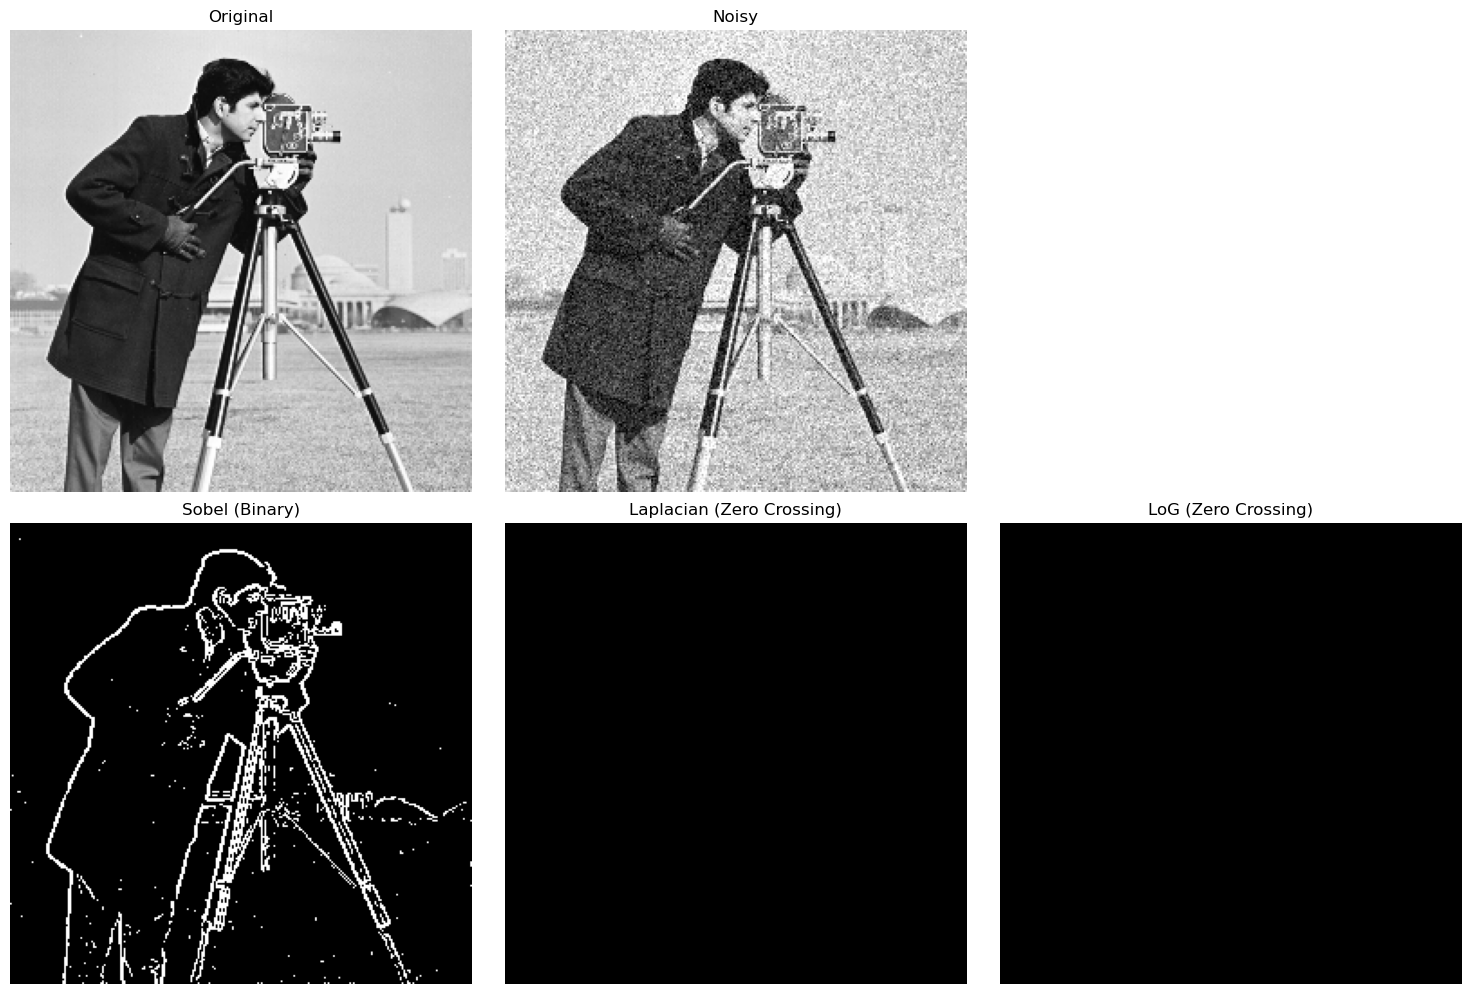

In [18]:
# Show all results together
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes[0,0].imshow(image, cmap='gray')
axes[0,0].set_title('Original')
axes[0,1].imshow(noisy_image, cmap='gray')
axes[0,1].set_title('Noisy')
axes[0,2].axis('off')

axes[1,0].imshow(sobel_binary, cmap='gray')
axes[1,0].set_title('Sobel (Binary)')
axes[1,1].imshow(laplacian_zc, cmap='gray')
axes[1,1].set_title('Laplacian (Zero Crossing)')
axes[1,2].imshow(log_zc, cmap='gray')
axes[1,2].set_title('LoG (Zero Crossing)')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()